# Sectoral Segmentation using Clustering Techniques

### **Industry**:
Indian Financial Services Sector

### **Objective**
The objective of this project is to segment companies in the Indian financial services sector based on their financial performance indicators using clustering techniques. The analysis aims to identify groups of companies with similar operational, profitability, liquidity, and growth characteristics.



## INTRODUCTION TO DATA

### Financial Ratios Selected


The following financial ratios were selected to capture different dimensions of company performance.

| Ratio | Category | Definition |
|---|---|---|
| Return on Equity (ROE) | Profitability | Measures profitability generated from shareholders' equity |
| Return on Assets (ROA) | Profitability | Measures efficiency in utilizing assets to generate profits |
| Current Ratio | Liquidity | Measures ability to meet short-term liabilities |
| Quick Ratio | Liquidity | Measures immediate liquidity excluding inventories |
| Total Revenue Growth (1 Year) | Growth | Measures yearly revenue expansion |
| Basic EPS | Growth / Profitability | Earnings generated per outstanding share |
| Total Asset Turnover | Efficiency | Measures efficiency of asset utilization |

### Imports and Installs

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import HDBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
!pip install yellowbrick

### Data Loading and Preprocessing

The dataset contains financial performance indicators of 50 companies from the Indian financial services sector.

The selected features are cleaned and normalized using MinMax Scaling to ensure all variables contribute equally during clustering.

In [3]:
# ==========================================
# Load Dataset
# ==========================================

data_file = "Finance.csv"

Finance_df = pd.read_csv(data_file)

Finance_df.head()

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover
0,Bajaj Finance Limited (NSEI:BAJFINANCE),"539,671.27",19.11,3.99,2.47,2.39,16.75,26.89,0.09
1,Bajaj Finserv Ltd. (NSEI:BAJAJFINSV),"308,798.60",15.12,5.05,0.29,0.17,20.62,55.61,0.22
2,Indian Railway Finance Corporation Limited (NS...,"162,546.08",12.77,1.34,8.53,8.51,1.60,4.98,0.01
3,Jio Financial Services Limited (NSEI:JIOFIN),"146,389.05",1.23,1.16,15.06,12.60,10.26,2.54,0.02
4,Bajaj Holdings & Investment Limited (BSE:500490),"132,459.87",9.77,0.48,53.36,53.14,-56.44,585.90,0.01


### Feature Selection and Scaling

In [4]:
# ==========================================
# Feature Selection
# ==========================================

x_features = [
    "Return on Equity",
    "Return on Assets",
    "Current Ratio",
    "Quick Ratio",
    "Total Revenue Growth (1 Year)",
    "Basic EPS",
    "total Asset Turnover"
]

# Convert columns to numeric
Finance_df[x_features] = Finance_df[x_features] \
    .replace(',', '', regex=True) \
    .astype(float)

# ==========================================
# Feature Scaling
# ==========================================

scaler = MinMaxScaler()

scaled_Finance_df = scaler.fit_transform(
    Finance_df[x_features]
)

scaled_Finance_df = pd.DataFrame(
    scaled_Finance_df,
    columns=x_features
)

scaled_Finance_df.head()

,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover
0,0.482955,0.286469,0.027999,0.029915,0.787195,0.057074,0.060606
1,0.401989,0.317581,0.000000,0.000000,0.817709,0.101090,0.159091
2,0.354302,0.208688,0.105831,0.112384,0.667744,0.023495,0.000000
3,0.120130,0.203405,0.189699,0.167498,0.736025,0.019755,0.007576
4,0.293425,0.183446,0.681608,0.713785,0.210124,0.913807,0.000000


## Part - 1 Exploratory Data Analysis (EDA)


EDA was performed to understand:
- feature distributions,
- presence of outliers,
- relationships among variables,
- correlation patterns across financial ratios.

This step helps identify dominant financial characteristics before segmentation.

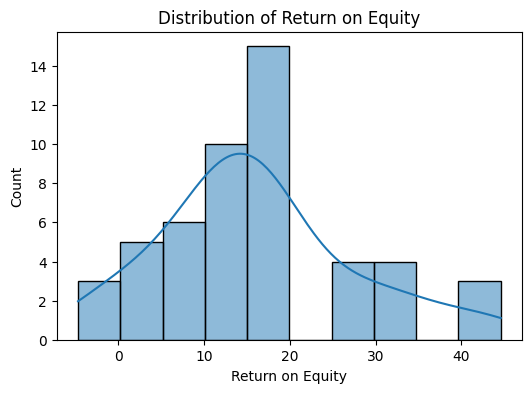

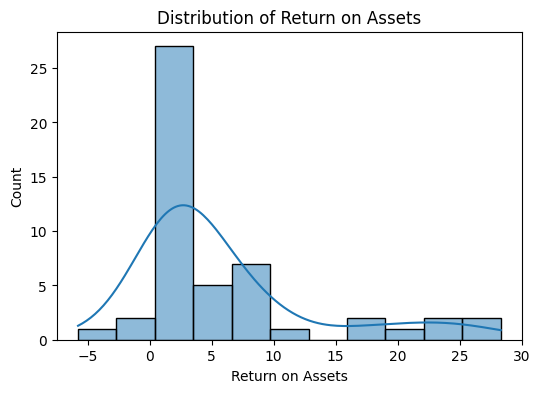

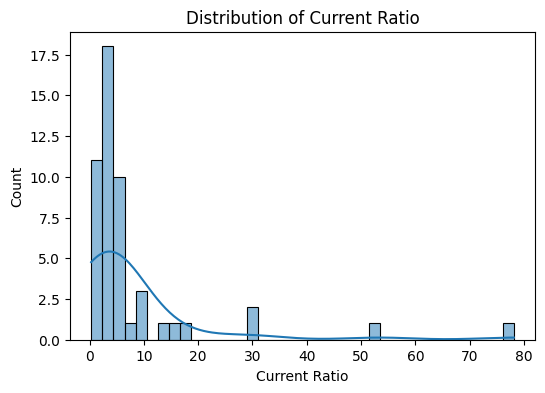

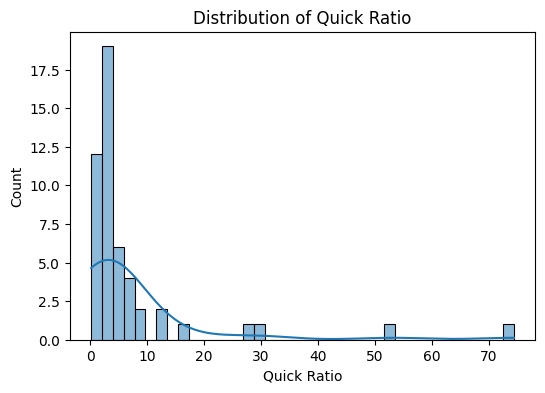

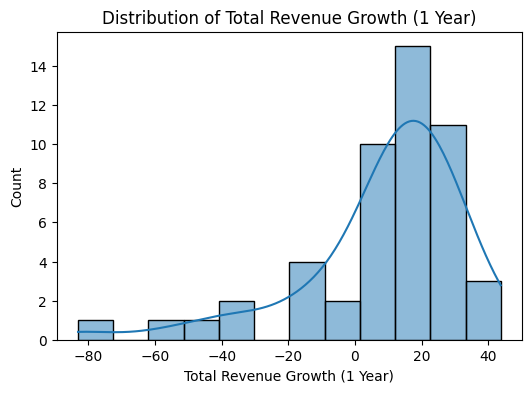

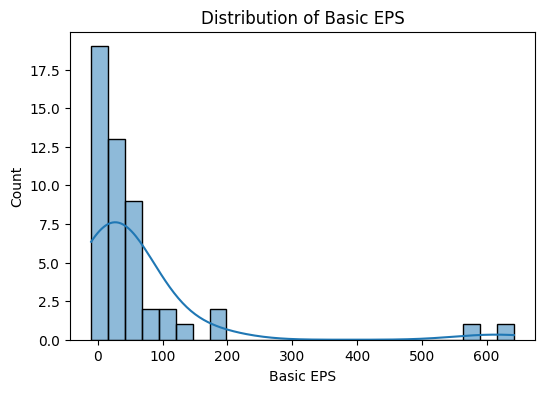

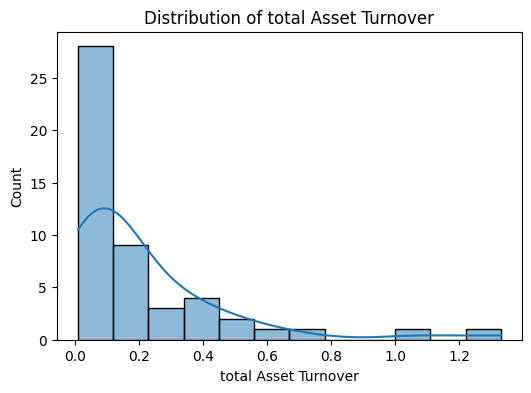

In [5]:
# ==========================================
# Distribution Plots
# ==========================================

for feature in x_features:

    plt.figure(figsize=(6,4))

    sn.histplot(
        Finance_df[feature],
        kde=True
    )

    plt.title(f"Distribution of {feature}")

    plt.show()

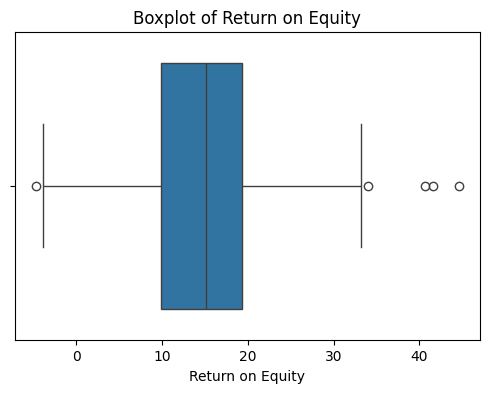

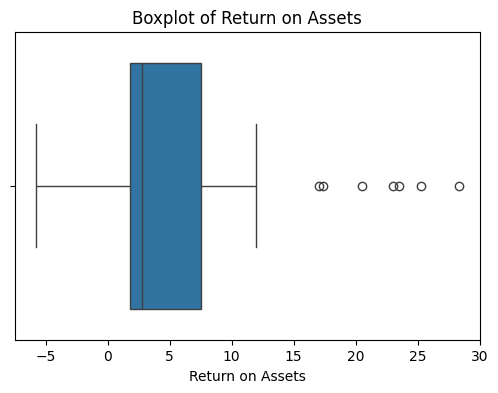

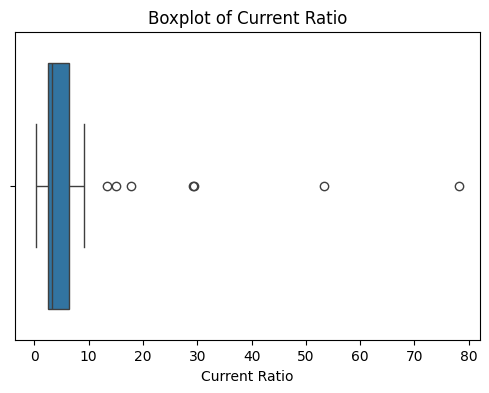

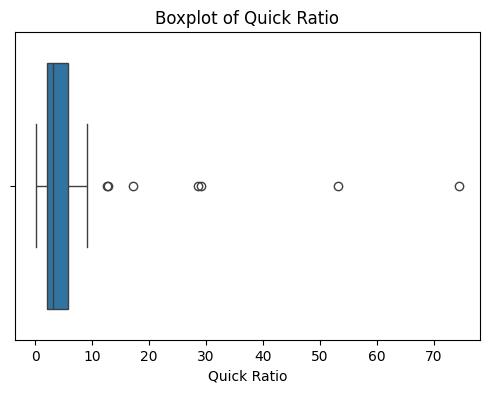

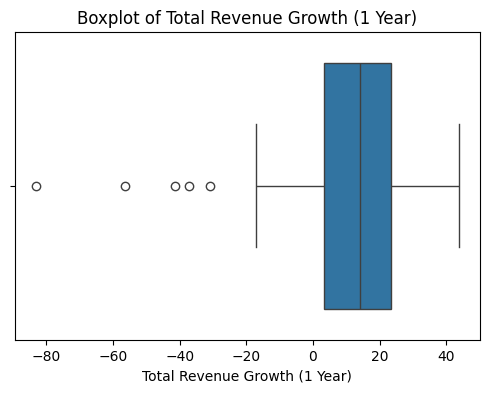

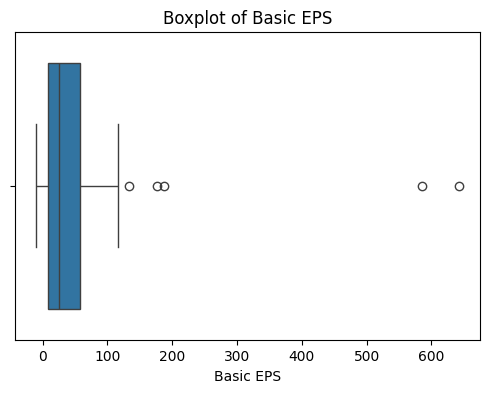

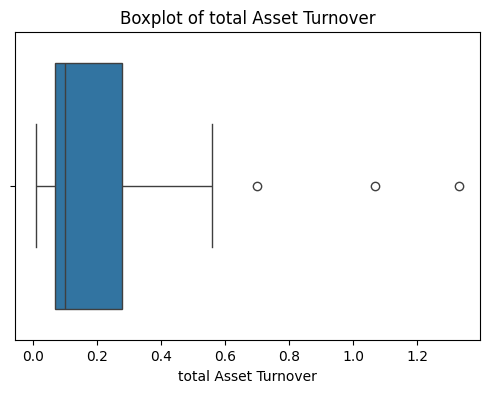

In [6]:
# ==========================================
# Boxplots for Outlier Detection
# ==========================================

for feature in x_features:

    plt.figure(figsize=(6,4))

    sn.boxplot(
        x=Finance_df[feature]
    )

    plt.title(f"Boxplot of {feature}")

    plt.show()

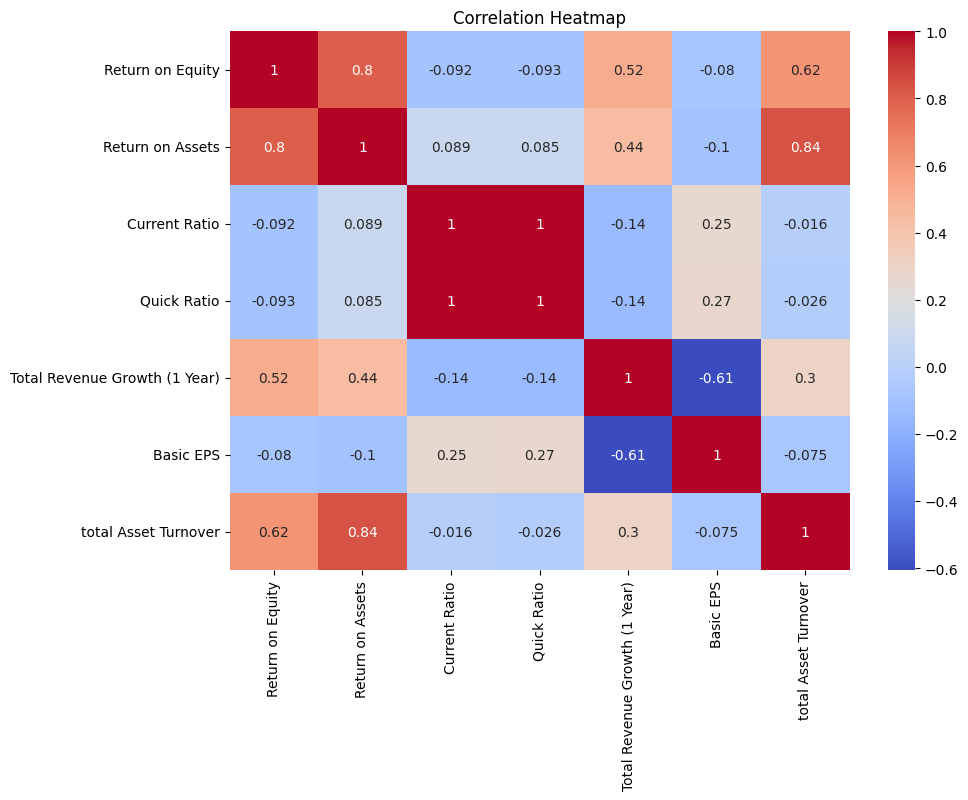

In [7]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,7))

sn.heatmap(
    Finance_df[x_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## PART - 2 Defining the number of clusters - Using Elbow method


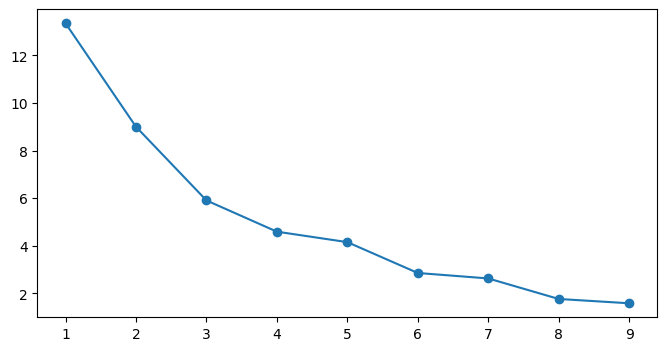

In [8]:
from sklearn.cluster import KMeans

cluster_range = range( 1, 10 )
cluster_errors = []

for num_clusters in cluster_range:
  clusters = KMeans(num_clusters)
  clusters.fit( scaled_Finance_df )
  cluster_errors.append( clusters.inertia_ )

plt.figure(figsize=(8,4))
plt.plot( cluster_range, cluster_errors, marker = "o" );

## PART - 3 Ranking the Clustors

### Quality verification of clusters - by Silhouette score method

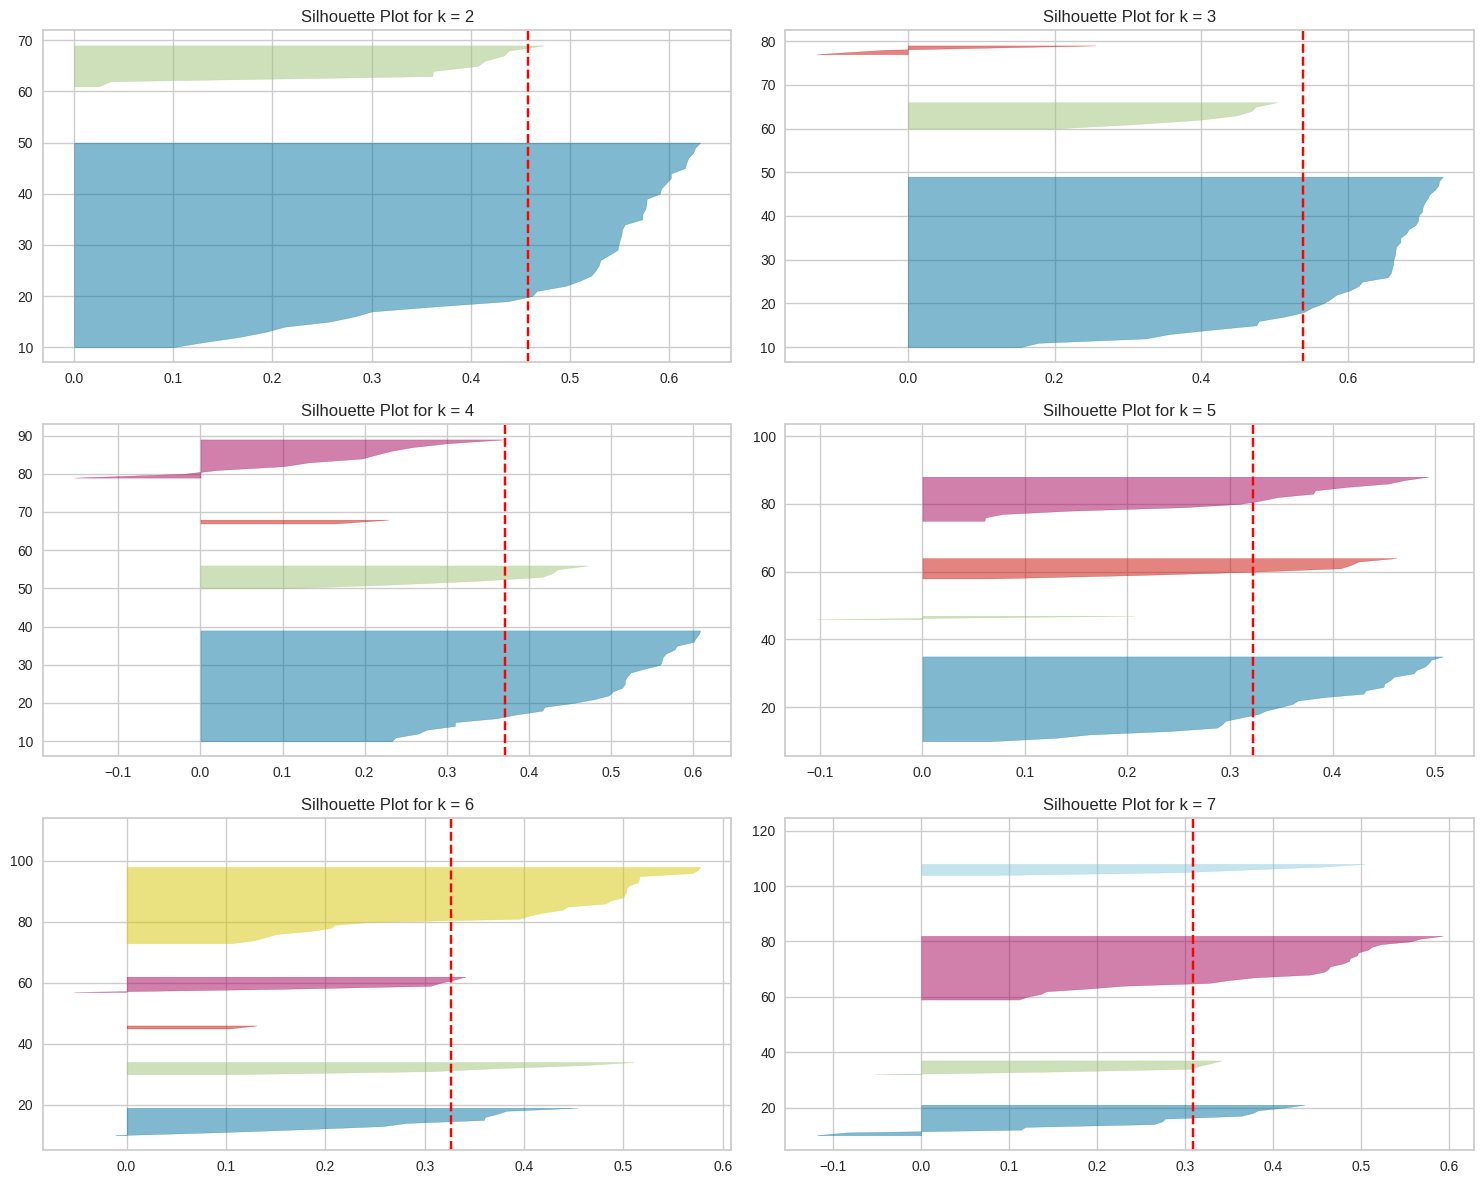

In [9]:
from yellowbrick.cluster import SilhouetteVisualizer

fig, ax = plt.subplots(3, 2, figsize=(15, 12))

num_clusters = [2, 3, 4, 5, 6, 7]

for i, k in enumerate(num_clusters):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    q, mod = divmod(i, 2)

    visualizer = SilhouetteVisualizer(
        km,
        colors='yellowbrick',
        ax=ax[q][mod]
    )

    visualizer.fit(scaled_Finance_df)

    # Add subplot title
    ax[q][mod].set_title(f"Silhouette Plot for k = {k}")

plt.tight_layout()

plt.show()

In [10]:
for k in [2, 3, 4, 5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_Finance_df)
    score = silhouette_score(scaled_Finance_df, kmeans.labels_)
    print(f"k = {k}, silhouette_score = {score:.3f}")

k = 2, silhouette_score = 0.457
k = 3, silhouette_score = 0.508
k = 4, silhouette_score = 0.453
k = 5, silhouette_score = 0.453
k = 6, silhouette_score = 0.369
k = 7, silhouette_score = 0.367


### Quality verification of clusters - by Calinski Harabasz score method

In [11]:
cluster_range = range(2, 8)
ch_scores = []

for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, random_state = 42 )
  clusters.fit( scaled_Finance_df )
  print(f"n_cluster: {num_clusters} - CH Score: {calinski_harabasz_score(scaled_Finance_df, clusters.labels_)}" )

n_cluster: 2 - CH Score: 23.43864156921145
n_cluster: 3 - CH Score: 29.623202963900837
n_cluster: 4 - CH Score: 24.22490933394049
n_cluster: 5 - CH Score: 26.516485437546617
n_cluster: 6 - CH Score: 27.741327540756316
n_cluster: 7 - CH Score: 29.25248625679346


### Cluster creation as per Shilouette and CH Scores

As Both Silhouette score and CH score are higher for K =3, It is selected for clustor formation

In [12]:
k = 3

clusters = KMeans( k, random_state = 42 )
clusters.fit(scaled_Finance_df )
Finance_df["clusterid"] = clusters.labels_

In [13]:
clusters.labels_

array([0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 0, 1, 0, 0], dtype=int32)

In [14]:
# Cluster 1

Finance_df[Finance_df.clusterid == 0]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid
0,Bajaj Finance Limited (NSEI:BAJFINANCE),"539,671.27",19.11,3.99,2.47,2.39,16.75,26.89,0.09,0
1,Bajaj Finserv Ltd. (NSEI:BAJAJFINSV),"308,798.60",15.12,5.05,0.29,0.17,20.62,55.61,0.22,0
2,Indian Railway Finance Corporation Limited (NS...,"162,546.08",12.77,1.34,8.53,8.51,1.60,4.98,0.01,0
3,Jio Financial Services Limited (NSEI:JIOFIN),"146,389.05",1.23,1.16,15.06,12.60,10.26,2.54,0.02,0
5,Cholamandalam Investment and Finance Company L...,"123,504.28",19.71,2.38,3.22,3.15,26.35,50.72,0.06,0
6,Shriram Finance Limited (BSE:511218),"119,921.48",17.78,3.48,2.51,2.41,15.90,50.82,0.07,0
7,Bajaj Housing Finance Limited (NSEI:BAJAJHFL),"101,345.22",13.44,2.34,9.05,9.05,22.73,2.67,0.04,0
8,Muthoot Finance Limited (NSEI:MUTHOOTFIN),"93,894.37",19.20,4.67,4.80,4.79,27.62,132.84,0.10,0
10,SBI Cards and Payment Services Limited (NSEI:S...,"82,016.48",14.82,3.10,1.42,1.40,-9.65,20.15,0.16,0
11,One97 Communications Limited (NSEI:PAYTM),"51,097.80",-4.69,-5.77,2.76,2.26,-30.84,-10.35,0.34,0


In [15]:
# Cluster 2

Finance_df[Finance_df.clusterid == 1]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid
9,HDFC Asset Management Company Limited (NSEI:HD...,"85,015.89",32.36,25.26,29.28,29.13,28.35,57.58,0.50,1
15,Nippon Life India Asset Management Limited (NS...,"36,127.27",31.39,23.50,29.31,28.66,23.73,20.33,0.56,1
21,ICICI Securities Limited,"29,148.63",41.55,6.98,1.21,0.61,13.97,60.20,0.17,1
27,Aditya Birla Sun Life AMC Limited (NSEI:ABSLAMC),"18,503.70",26.99,20.52,17.70,17.22,21.15,32.26,0.52,1
28,KFin Technologies Limited (NSEI:KFINTECH),"17,759.86",26.10,17.03,5.23,5.04,28.72,19.39,0.70,1
30,Indian Energy Exchange Limited (NSEI:IEX),"15,715.32",40.71,17.40,1.57,1.18,19.33,4.83,0.33,1
32,Anand Rathi Wealth Limited (NSEI:ANANDRATHI),"15,216.85",44.59,28.30,2.68,0.98,30.41,36.05,1.07,1
41,Prudent Corporate Advisory Services Limited (N...,"9,184.42",34.05,23.00,3.06,2.12,37.45,47.25,1.33,1
47,IIFL Capital Services Limited (NSEI:IIFLCAPS),"6,691.02",33.17,9.01,6.28,3.17,12.69,23.06,0.30,1


In [16]:
# Cluster 3

Finance_df[Finance_df.clusterid == 2]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid
4,Bajaj Holdings & Investment Limited (BSE:500490),"132,459.87",9.77,0.48,53.36,53.14,-56.44,585.90,0.01,2
24,Piramal Enterprises Limited,"22,282.83",1.81,0.55,78.15,74.38,2.49,21.56,0.07,2
45,Bengal & Assam Company Limited (BSE:533095),"8,272.02",7.86,2.41,3.60,2.81,-83.09,642.14,0.20,2


## PART - 4 Ranking the features - Using F Score method

In [17]:
model = KMeans(n_clusters=3, random_state = 42)
model.fit(scaled_Finance_df)

KMeans(n_clusters=3, random_state=42)

In [18]:
from sklearn.feature_selection import f_classif
import numpy as np

X = scaled_Finance_df
y = model.labels_

f_scores, p_vals = f_classif(X, y)
importance = pd.Series(f_scores, index=x_features).sort_values(ascending=False)
print(importance)

Return on Assets                 58.818772
Return on Equity                 37.563456
Basic EPS                        29.360616
total Asset Turnover             26.291093
Current Ratio                    25.454259
Quick Ratio                      24.965027
Total Revenue Growth (1 Year)    14.338390
dtype: float64


In [19]:
f_scores_df = pd.DataFrame( {"features": x_features,
                             "f_scores": f_scores,
                             "p_values": p_vals} )

In [20]:
f_scores_df.sort_values("p_values")

,features,f_scores,p_values
1,Return on Assets,58.818772,1.606464e-13
0,Return on Equity,37.563456,1.795694e-10
5,Basic EPS,29.360616,5.327061e-09
6,total Asset Turnover,26.291093,2.172855e-08
2,Current Ratio,25.454259,3.236074e-08
3,Quick Ratio,24.965027,4.097567e-08
4,Total Revenue Growth (1 Year),14.338390,1.376187e-05


In [21]:
Finance_df['clusterid'] = model.labels_

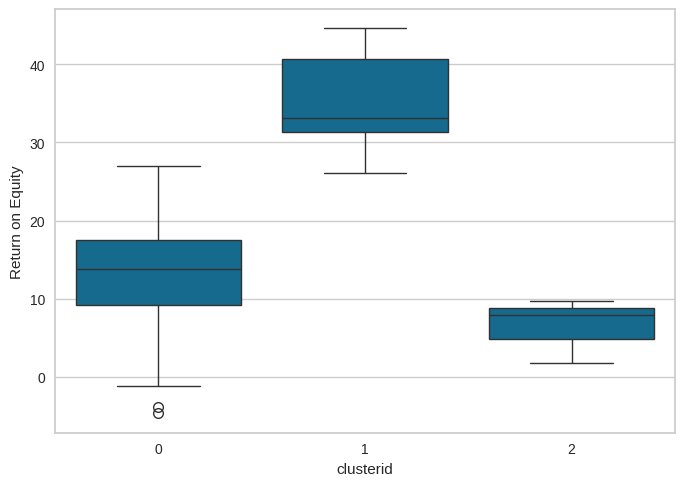

In [22]:
sn.boxplot(Finance_df,
            y = 'Return on Equity',
            x = 'clusterid');

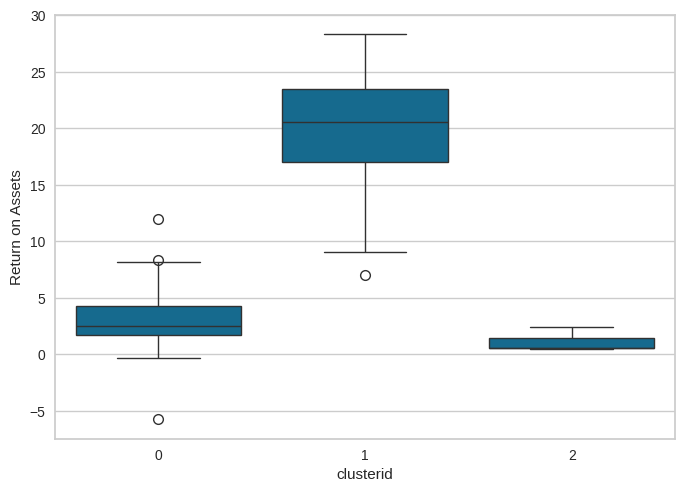

In [23]:
sn.boxplot(Finance_df,
            y = 'Return on Assets',
            x = 'clusterid');

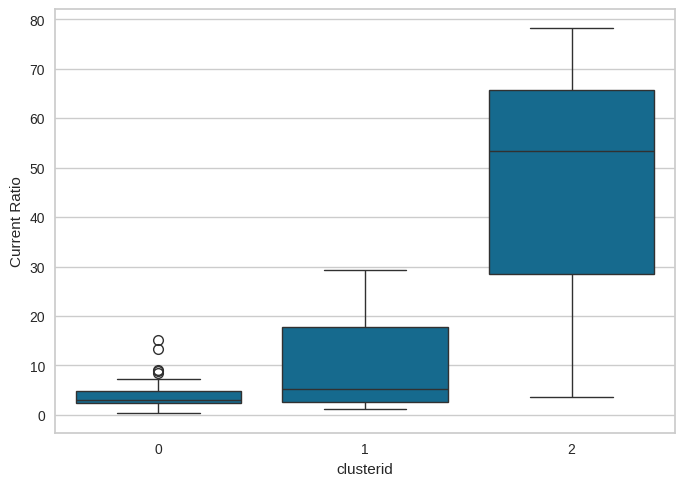

In [24]:
sn.boxplot(Finance_df,
            y = 'Current Ratio',
            x = 'clusterid');

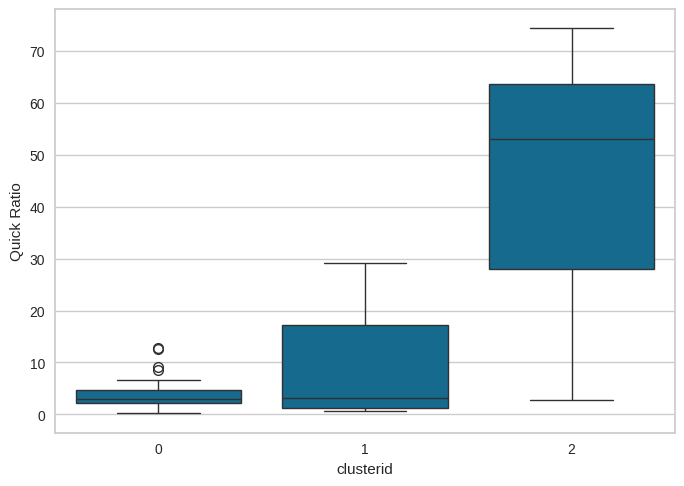

In [25]:
sn.boxplot(Finance_df,
            y = 'Quick Ratio',
            x = 'clusterid');

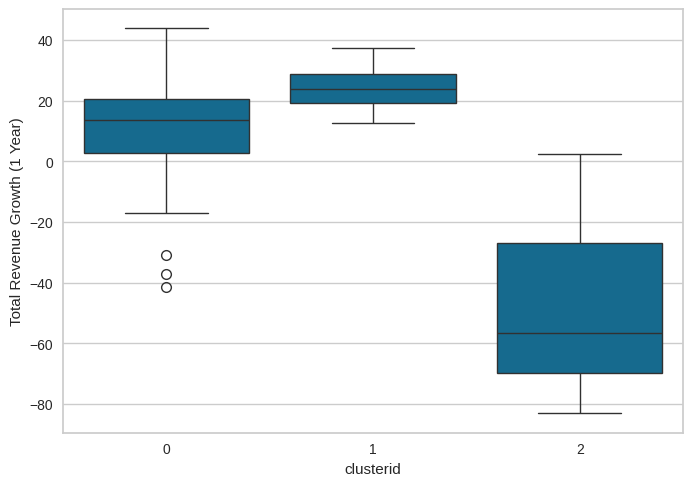

In [26]:
sn.boxplot(Finance_df,
            y = 'Total Revenue Growth (1 Year)',
            x = 'clusterid');

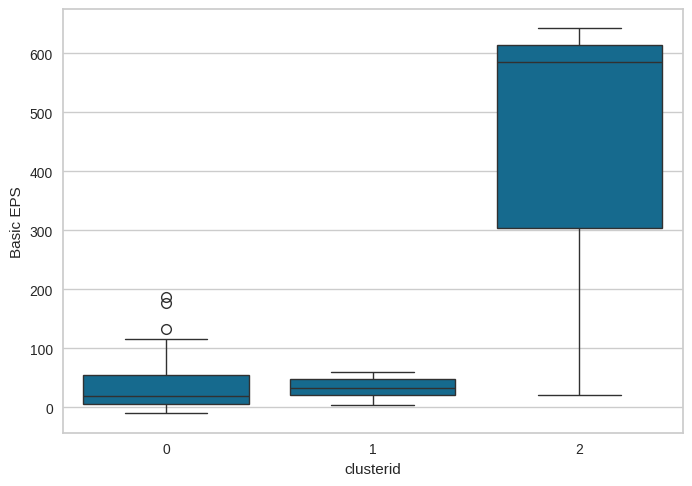

In [27]:
sn.boxplot(Finance_df,
            y = 'Basic EPS',
            x = 'clusterid');

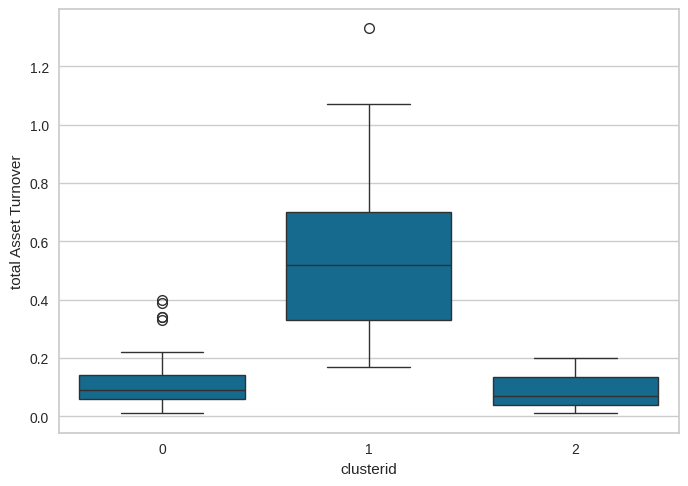

In [28]:
sn.boxplot(Finance_df,
            y = 'total Asset Turnover',
            x = 'clusterid');

## PART - 5 Hierarchical Clustering

In [29]:
agcluster = AgglomerativeClustering(n_clusters = 3, linkage = 'ward')

In [30]:
agcluster.fit(scaled_Finance_df)

AgglomerativeClustering(n_clusters=3)

In [31]:
agcluster.labels_

array([0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 0, 0, 0, 0])

In [32]:
Finance_df['agcl_id'] = agcluster.labels_

In [33]:
Finance_df.sort_values('agcl_id', ascending = True)

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid,agcl_id
0,Bajaj Finance Limited (NSEI:BAJFINANCE),"539,671.27",19.11,3.99,2.47,2.39,16.75,26.89,0.09,0,0
1,Bajaj Finserv Ltd. (NSEI:BAJAJFINSV),"308,798.60",15.12,5.05,0.29,0.17,20.62,55.61,0.22,0,0
2,Indian Railway Finance Corporation Limited (NS...,"162,546.08",12.77,1.34,8.53,8.51,1.60,4.98,0.01,0,0
3,Jio Financial Services Limited (NSEI:JIOFIN),"146,389.05",1.23,1.16,15.06,12.60,10.26,2.54,0.02,0,0
5,Cholamandalam Investment and Finance Company L...,"123,504.28",19.71,2.38,3.22,3.15,26.35,50.72,0.06,0,0
6,Shriram Finance Limited (BSE:511218),"119,921.48",17.78,3.48,2.51,2.41,15.90,50.82,0.07,0,0
7,Bajaj Housing Finance Limited (NSEI:BAJAJHFL),"101,345.22",13.44,2.34,9.05,9.05,22.73,2.67,0.04,0,0
8,Muthoot Finance Limited (NSEI:MUTHOOTFIN),"93,894.37",19.20,4.67,4.80,4.79,27.62,132.84,0.10,0,0
14,L&T Finance Limited (NSEI:LTF),"37,310.68",10.76,2.37,2.04,1.88,5.43,10.61,0.07,0,0
10,SBI Cards and Payment Services Limited (NSEI:S...,"82,016.48",14.82,3.10,1.42,1.40,-9.65,20.15,0.16,0,0


In [34]:
# ==========================================
# Recreate Clean Scaled Data
# ==========================================

scaled_Finance_df = pd.DataFrame(
    scaler.fit_transform(Finance_df[x_features]),
    columns=x_features,
    index=Finance_df['Company Name']
)


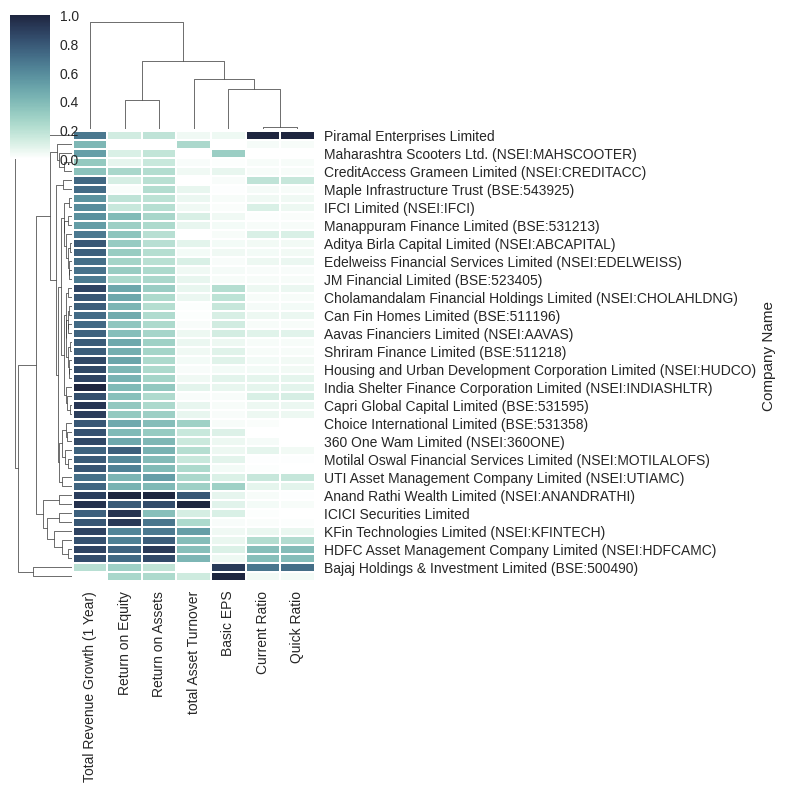

In [35]:
cmap = sn.cubehelix_palette(as_cmap=True, rot=-.3, light=1)
sn.clustermap(scaled_Finance_df,
              cmap=cmap,
              linewidths=.2,
              figsize = (8,8));

## PART- 6 Clustering algorithm to find outliers - HDBSCAN Algorithm

In [36]:
hscan = HDBSCAN(min_cluster_size=2)

In [37]:
x_features

['Return on Equity',
 'Return on Assets',
 'Current Ratio',
 'Quick Ratio',
 'Total Revenue Growth (1 Year)',
 'Basic EPS',
 'total Asset Turnover']

In [38]:
hscan.fit(scaled_Finance_df[x_features])

HDBSCAN(min_cluster_size=2)

In [39]:
hscan.labels_

array([ 2,  2,  2,  2, -1,  2,  2,  2,  2,  1,  2, -1,  2,  2,  2,  1,  2,
        2,  2,  2,  2,  2,  2,  2, -1,  2,  2,  1,  1,  2, -1,  2,  0,  2,
        2,  3, -1,  2,  2,  2,  2,  0,  2,  2,  2, -1,  2,  2,  3,  2])

In [40]:
Finance_df.drop(columns = ['agcl_id'], inplace = True)

In [41]:
Finance_df['hscan_cluster'] = hscan.labels_

In [42]:
Finance_df[Finance_df.hscan_cluster == 0]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid,hscan_cluster
32,Anand Rathi Wealth Limited (NSEI:ANANDRATHI),"15,216.85",44.59,28.3,2.68,0.98,30.41,36.05,1.07,1,0
41,Prudent Corporate Advisory Services Limited (N...,"9,184.42",34.05,23.0,3.06,2.12,37.45,47.25,1.33,1,0


In [43]:
Finance_df[Finance_df.hscan_cluster == 1]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid,hscan_cluster
9,HDFC Asset Management Company Limited (NSEI:HD...,"85,015.89",32.36,25.26,29.28,29.13,28.35,57.58,0.50,1,1
15,Nippon Life India Asset Management Limited (NS...,"36,127.27",31.39,23.50,29.31,28.66,23.73,20.33,0.56,1,1
27,Aditya Birla Sun Life AMC Limited (NSEI:ABSLAMC),"18,503.70",26.99,20.52,17.70,17.22,21.15,32.26,0.52,1,1
28,KFin Technologies Limited (NSEI:KFINTECH),"17,759.86",26.10,17.03,5.23,5.04,28.72,19.39,0.70,1,1


In [44]:
Finance_df[Finance_df.hscan_cluster == 2]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid,hscan_cluster
0,Bajaj Finance Limited (NSEI:BAJFINANCE),"539,671.27",19.11,3.99,2.47,2.39,16.75,26.89,0.09,0,2
1,Bajaj Finserv Ltd. (NSEI:BAJAJFINSV),"308,798.60",15.12,5.05,0.29,0.17,20.62,55.61,0.22,0,2
2,Indian Railway Finance Corporation Limited (NS...,"162,546.08",12.77,1.34,8.53,8.51,1.60,4.98,0.01,0,2
3,Jio Financial Services Limited (NSEI:JIOFIN),"146,389.05",1.23,1.16,15.06,12.60,10.26,2.54,0.02,0,2
5,Cholamandalam Investment and Finance Company L...,"123,504.28",19.71,2.38,3.22,3.15,26.35,50.72,0.06,0,2
6,Shriram Finance Limited (BSE:511218),"119,921.48",17.78,3.48,2.51,2.41,15.90,50.82,0.07,0,2
7,Bajaj Housing Finance Limited (NSEI:BAJAJHFL),"101,345.22",13.44,2.34,9.05,9.05,22.73,2.67,0.04,0,2
8,Muthoot Finance Limited (NSEI:MUTHOOTFIN),"93,894.37",19.20,4.67,4.80,4.79,27.62,132.84,0.10,0,2
10,SBI Cards and Payment Services Limited (NSEI:S...,"82,016.48",14.82,3.10,1.42,1.40,-9.65,20.15,0.16,0,2
12,Aditya Birla Capital Limited (NSEI:ABCAPITAL),"47,976.82",11.09,1.32,3.45,3.34,18.01,12.80,0.12,0,2


In [45]:
Finance_df[Finance_df.hscan_cluster == 3]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid,hscan_cluster
35,UTI Asset Management Company Limited (NSEI:UTI...,"13,592.44",16.05,12.00,13.28,12.76,6.57,57.33,0.34,0,3
48,ICRA Limited (NSEI:ICRA),"5,342.50",16.80,8.14,6.37,6.24,11.64,176.73,0.40,0,3


In [46]:
Finance_df[Finance_df.hscan_cluster == -1]

,Company Name,Market Cap in INR (crore) apr 1 2025,Return on Equity,Return on Assets,Current Ratio,Quick Ratio,Total Revenue Growth (1 Year),Basic EPS,total Asset Turnover,clusterid,hscan_cluster
4,Bajaj Holdings & Investment Limited (BSE:500490),"132,459.87",9.77,0.48,53.36,53.14,-56.44,585.90,0.01,2,-1
11,One97 Communications Limited (NSEI:PAYTM),"51,097.80",-4.69,-5.77,2.76,2.26,-30.84,-10.35,0.34,0,-1
24,Piramal Enterprises Limited,"22,282.83",1.81,0.55,78.15,74.38,2.49,21.56,0.07,2,-1
30,Indian Energy Exchange Limited (NSEI:IEX),"15,715.32",40.71,17.40,1.57,1.18,19.33,4.83,0.33,1,-1
36,Maharashtra Scooters Ltd. (NSEI:MAHSCOOTER),"12,212.80",0.74,0.34,0.71,0.53,-17.15,187.56,0.01,0,-1
45,Bengal & Assam Company Limited (BSE:533095),"8,272.02",7.86,2.41,3.60,2.81,-83.09,642.14,0.20,2,-1
